# Student Usage Metrics
## Comparing Group A vs Group B 

In [26]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the data
df_group_a = pd.read_csv('base_exports/base_usage_20260203_to_20260209.csv', encoding='latin-1')
df_group_b = pd.read_csv('database_exports/students_usage_20260203_to_20260209.csv', encoding='latin-1')

# Add group identifier
df_group_a['group'] = 'A'
df_group_b['group'] = 'B'

# Combine datasets
df_combined = pd.concat([df_group_a, df_group_b], ignore_index=True)

print(f"Group A: {len(df_group_a)} students")
print(f"Group B: {len(df_group_b)} students")
print(f"Total: {len(df_combined)} students")

# Display first few rows to verify data structure
print("\nGroup A Sample:")
print(df_group_a.head())
print("\nGroup B Sample:")
print(df_group_b.head())
print("\nColumn names:")
print(df_combined.columns.tolist())

Group A: 20 students
Group B: 28 students
Total: 48 students

Group A Sample:
     student_email                         user_id  total_conv  \
0  ppk5368@psu.edu  auth0|697501db873ec3263f2b7a5d          11   
1  seh6000@psu.edu  auth0|697501fedf883e25ebd47dd6           1   
2  mjw6852@psu.edu  auth0|69750259873ec3263f2b7aaf          12   
3  ase5245@psu.edu  auth0|69750293df883e25ebd47e4a          14   
4  rks6004@psu.edu  auth0|697502cddf883e25ebd47e7b          11   

   avg_msg_per_conv  mdn_msg_per_conv  avg_char_per_msg  mdn_char_per_msg  \
0              1.00               1.0           1031.09            1074.0   
1              1.00               1.0           1824.00            1824.0   
2              3.08               3.0            139.97              35.0   
3              6.36               4.0            173.98              98.0   
4              4.27               4.0            304.09             125.0   

  last_conv_date  last_conv_user_msg group  
0     02-05-2026 

In [27]:
# Define metrics to visualize
metrics = [
    'total_conv',
    'avg_msg_per_conv',
    'mdn_msg_per_conv',
    'avg_char_per_msg',
    'mdn_char_per_msg',
    'last_conv_user_msg'
]

# Define metric labels for better readability
metric_labels = {
    'total_conv': 'Total Conversations',
    'avg_msg_per_conv': 'Avg Messages per Conversation',
    'mdn_msg_per_conv': 'Median Messages per Conversation',
    'avg_char_per_msg': 'Avg Characters per Message',
    'mdn_char_per_msg': 'Median Characters per Message',
    'last_conv_user_msg': 'Messages in Last Conversation'
}

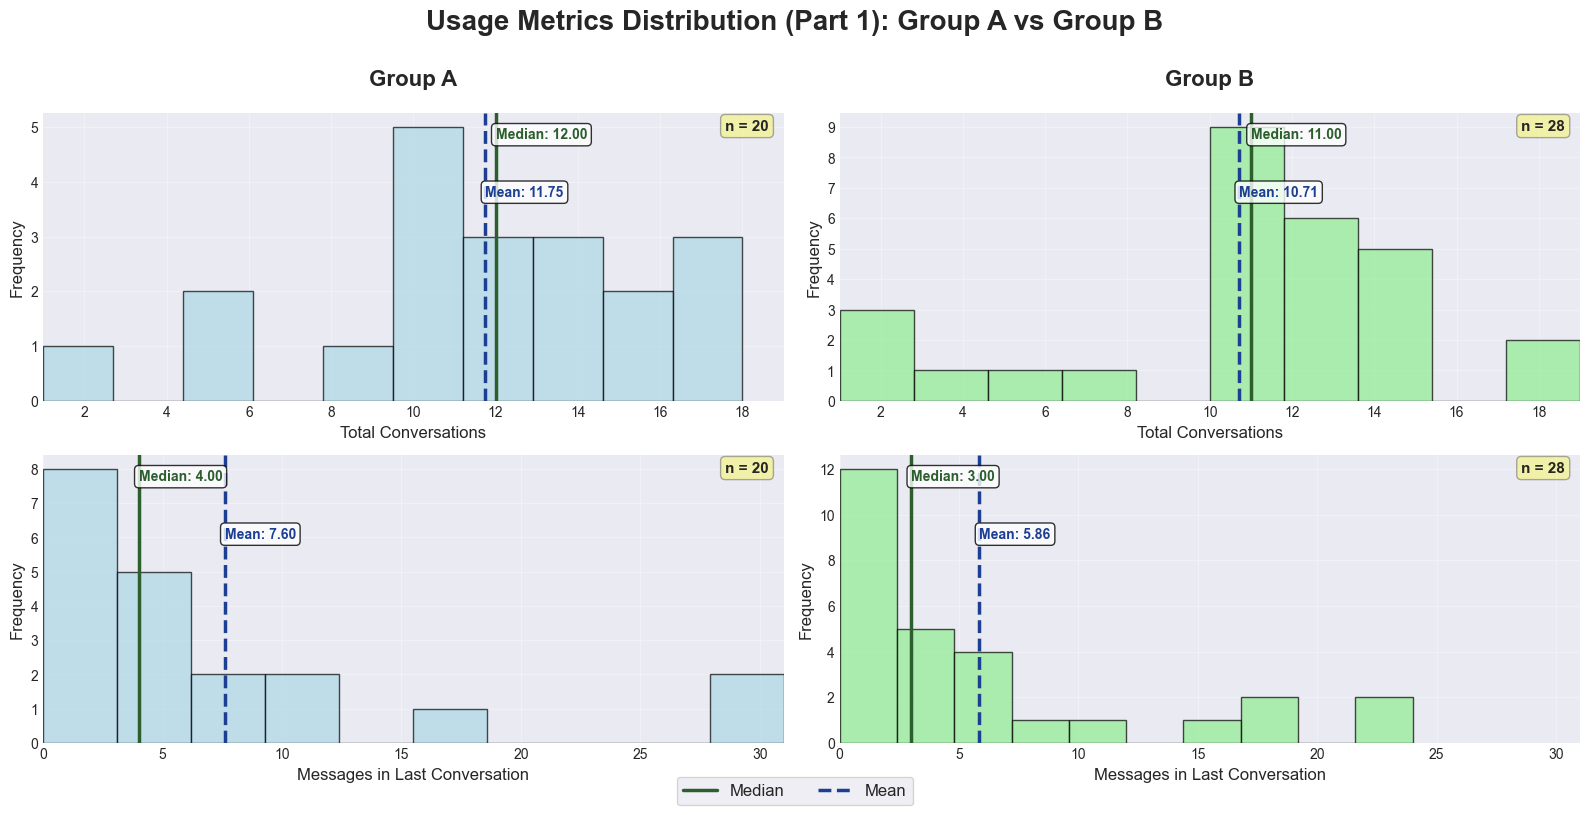


Figure saved as: aa_usage_02_03_part1.png


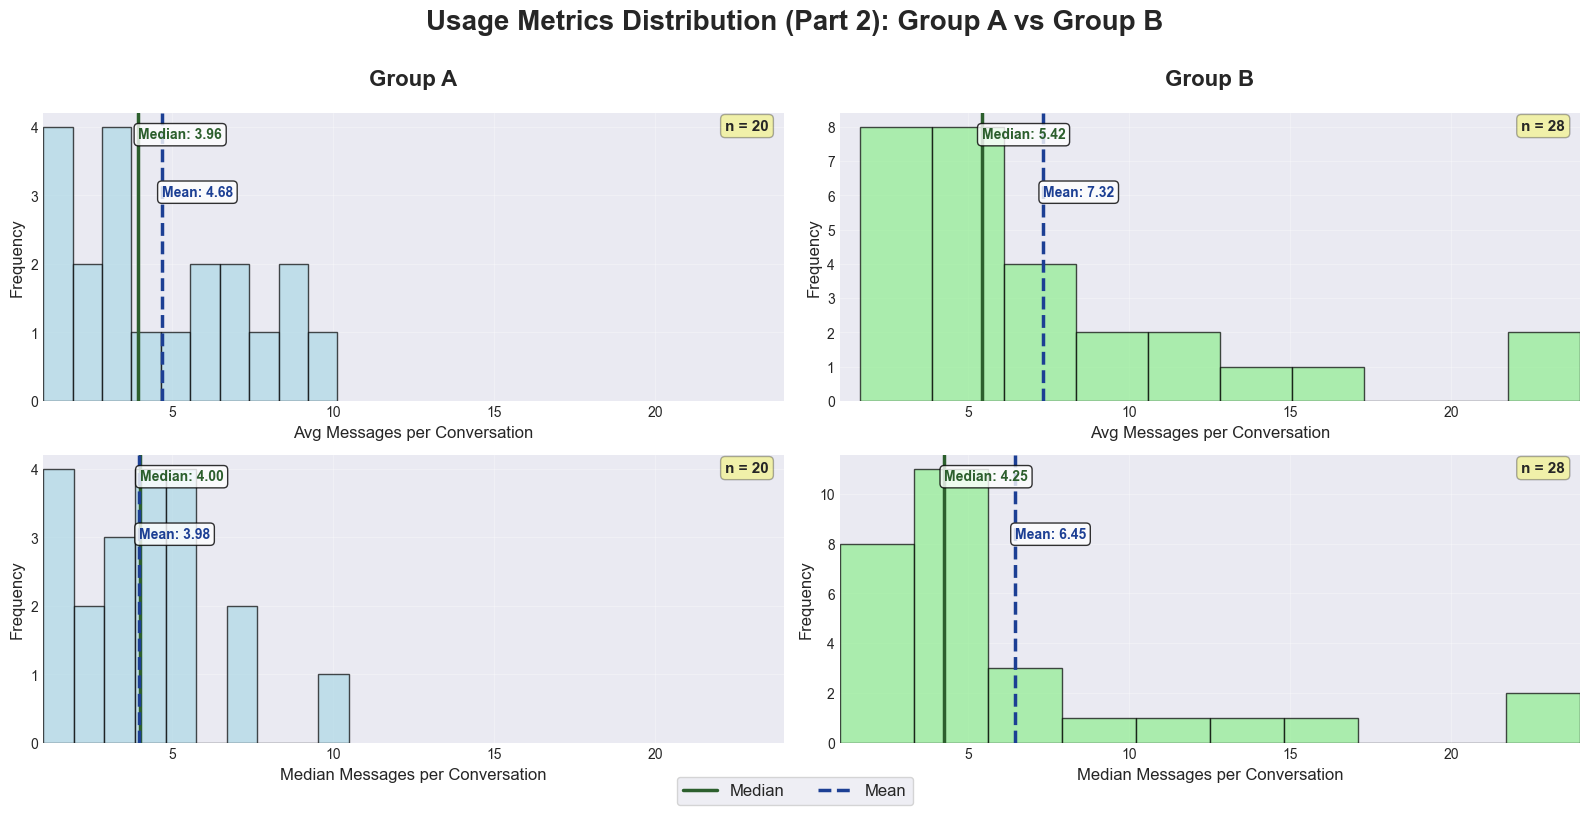


Figure saved as: aa_usage_02_03_part2.png


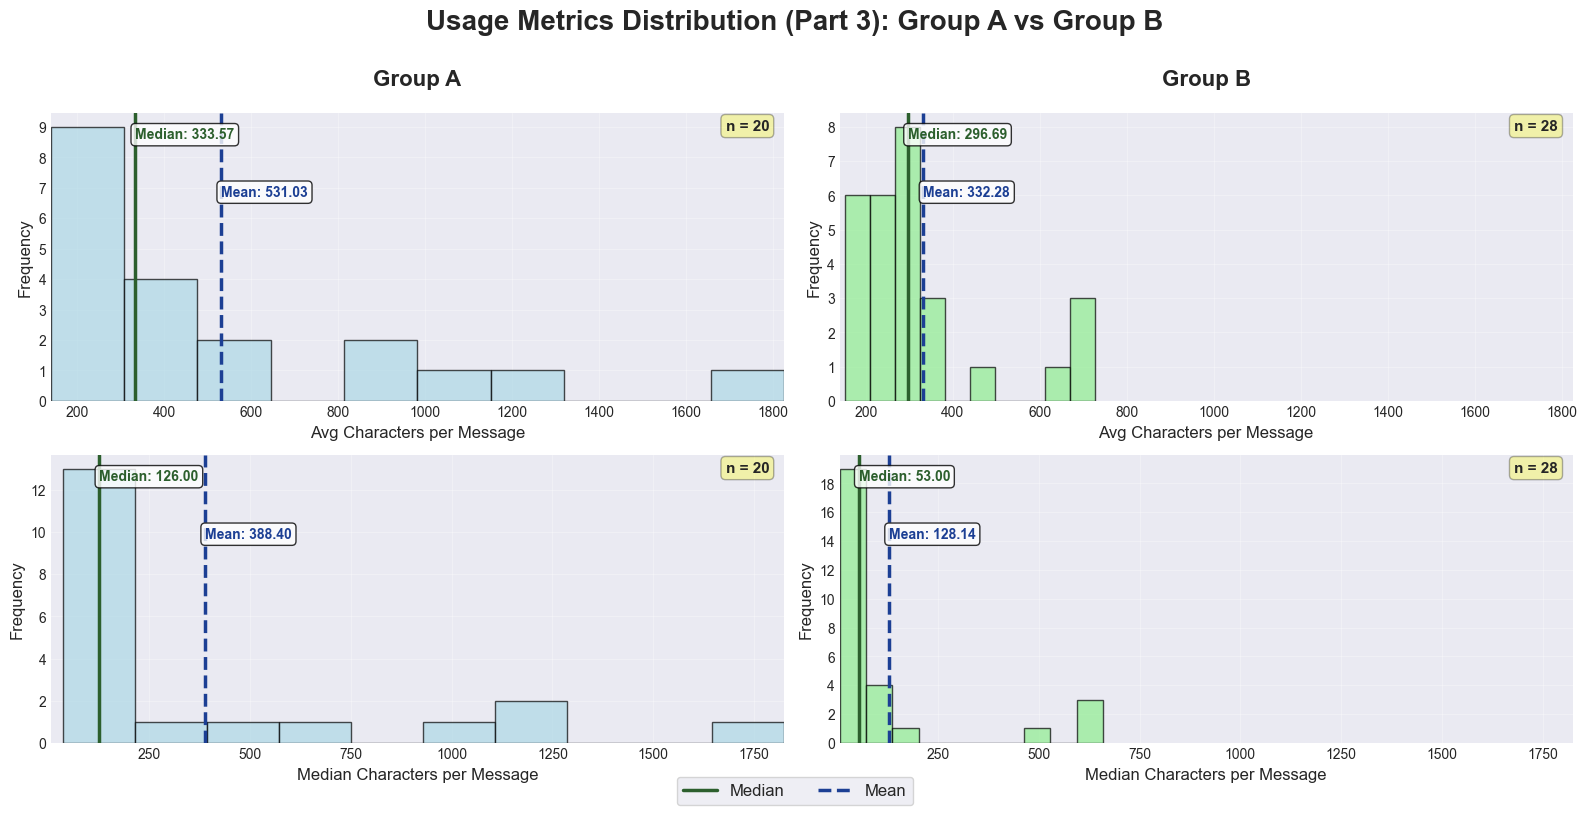


Figure saved as: aa_usage_02_03_part3.png

All histograms generated successfully!


In [28]:
# Define colors
color_group_a = '#ADD8E6'  # Light blue
color_group_b = '#90EE90'  # Light green
color_median = '#2C5F2D'   # Dark green for median (solid line)
color_mean = '#1C3F94'     # Dark blue for mean (dashed line)

# Split metrics into two groups
metrics_fig1 = [
    'total_conv',
    'last_conv_user_msg'
]
metrics_fig2 = [
    'avg_msg_per_conv',
    'mdn_msg_per_conv'
]

metrics_fig3 = [
    'avg_char_per_msg',
    'mdn_char_per_msg'
]

def create_histogram_figure(metrics_list, fig_title, output_filename, nrows):
    """Helper function to create histogram figures"""
    fig, axes = plt.subplots(nrows, 2, figsize=(16, nrows * 4))
    fig.suptitle(fig_title, fontsize=20, fontweight='bold', y=0.995)
    
    # Handle single row case
    if nrows == 1:
        axes = axes.reshape(1, -1)
    
    # Add column headers
    axes[0, 0].set_title('Group A', fontsize=16, fontweight='bold', pad=20)
    axes[0, 1].set_title('Group B', fontsize=16, fontweight='bold', pad=20)
    
    # Iterate through metrics
    for idx, metric in enumerate(metrics_list):
        # Get data for both groups
        data_a = df_group_a[metric].dropna()
        data_b = df_group_b[metric].dropna()
        
        # Calculate statistics
        mean_a = data_a.mean()
        median_a = data_a.median()
        n_a = len(data_a)
        
        mean_b = data_b.mean()
        median_b = data_b.median()
        n_b = len(data_b)
        
        # Determine shared x-axis range
        x_min = min(data_a.min(), data_b.min())
        x_max = max(data_a.max(), data_b.max())
        
        # Calculate number of bins (using Sturges' rule)
        n_bins = int(np.ceil(np.log2(max(n_a, n_b)) + 1))
        n_bins = max(n_bins, 10)  # Minimum 10 bins
        
        # Plot Group A
        ax_a = axes[idx, 0]
        ax_a.hist(data_a, bins=n_bins, color=color_group_a, edgecolor='black', alpha=0.7)
        ax_a.set_xlim(x_min, x_max)
        ax_a.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
        
        # Add median line (solid) and label for Group A
        y_max_a = ax_a.get_ylim()[1]
        ax_a.axvline(median_a, color=color_median, linestyle='-', linewidth=2.5, label='Median')
        ax_a.text(median_a, y_max_a * 0.95, f'Median: {median_a:.2f}', 
                  ha='left', va='top', fontsize=10, fontweight='bold',
                  color=color_median, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Add mean line (dashed) and label for Group A
        ax_a.axvline(mean_a, color=color_mean, linestyle='--', linewidth=2.5, label='Mean')
        ax_a.text(mean_a, y_max_a * 0.75, f'Mean: {mean_a:.2f}', 
                  ha='left', va='top', fontsize=10, fontweight='bold',
                  color=color_mean, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Add sample size
        ax_a.text(0.98, 0.98, f'n = {n_a}', transform=ax_a.transAxes,
                  ha='right', va='top', fontsize=11, fontweight='bold',
                  bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
        
        ax_a.set_ylabel('Frequency', fontsize=12)
        ax_a.set_xlabel(metric_labels[metric], fontsize=12)
        ax_a.grid(True, alpha=0.3)
        
        # Plot Group B
        ax_b = axes[idx, 1]
        ax_b.hist(data_b, bins=n_bins, color=color_group_b, edgecolor='black', alpha=0.7)
        ax_b.set_xlim(x_min, x_max)
        ax_b.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
        
        # Add median line (solid) and label for Group B
        y_max_b = ax_b.get_ylim()[1]
        ax_b.axvline(median_b, color=color_median, linestyle='-', linewidth=2.5, label='Median')
        ax_b.text(median_b, y_max_b * 0.95, f'Median: {median_b:.2f}', 
                  ha='left', va='top', fontsize=10, fontweight='bold',
                  color=color_median, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Add mean line (dashed) and label for Group B
        ax_b.axvline(mean_b, color=color_mean, linestyle='--', linewidth=2.5, label='Mean')
        ax_b.text(mean_b, y_max_b * 0.75, f'Mean: {mean_b:.2f}', 
                  ha='left', va='top', fontsize=10, fontweight='bold',
                  color=color_mean, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Add sample size
        ax_b.text(0.98, 0.98, f'n = {n_b}', transform=ax_b.transAxes,
                  ha='right', va='top', fontsize=11, fontweight='bold',
                  bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
        
        ax_b.set_ylabel('Frequency', fontsize=12)
        ax_b.set_xlabel(metric_labels[metric], fontsize=12)
        ax_b.grid(True, alpha=0.3)
    
    # Add legend at the bottom
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=12, 
               bbox_to_anchor=(0.5, -0.01), frameon=True)
    
    plt.tight_layout(rect=[0, 0.01, 1, 0.99])
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nFigure saved as: {output_filename}")

# Create Figure 1: Conversation and Message Metrics
create_histogram_figure(
    metrics_fig1,
    'Usage Metrics Distribution (Part 1): Group A vs Group B',
    'aa_usage_02_03_part1.png',
    nrows=2
)

# Create Figure 2: Character Metrics
create_histogram_figure(
    metrics_fig2,
    'Usage Metrics Distribution (Part 2): Group A vs Group B',
    'aa_usage_02_03_part2.png',
    nrows=2
)

# Create Figure 3: Conversation and Message Metrics
create_histogram_figure(
    metrics_fig3,
    'Usage Metrics Distribution (Part 3): Group A vs Group B',
    'aa_usage_02_03_part3.png',
    nrows=2
)

print("\n" + "="*60)
print("All histograms generated successfully!")
print("="*60)

In [ ]:
# Generate summary statistics table
summary_data = []

for metric in metrics:
    data_a = df_group_a[metric].dropna()
    data_b = df_group_b[metric].dropna()
    
    summary_data.append({
        'Metric': metric_labels[metric],
        'Group A Mean': f"{data_a.mean():.2f}",
        'Group A Median': f"{data_a.median():.2f}",
        'Group A Std': f"{data_a.std():.2f}",
        'Group B Mean': f"{data_b.mean():.2f}",
        'Group B Median': f"{data_b.median():.2f}",
        'Group B Std': f"{data_b.std():.2f}",
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("SUMMARY STATISTICS")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)

In [ ]:
# Save summary statistics to CSV
summary_df.to_csv('summary_statistics.csv', index=False)
print("\nSummary statistics saved to: summary_statistics.csv")